In [1]:
# Import 

import pandas as pd

# read csv without columns
huzasok = pd.read_csv("otos.csv", sep=";", header=None, 
                      names=["year", "week", "date", "fives", "fives_prize", "fours", "fours_prize", "threes", "threes_prize", "twos", "twos_prize", "n1", "n2", "n3", "n4", "n5"])
display(huzasok)

# szelvények árai időben
szelo_arak = {'elotte': 130,
              '2003.04.': 150,
              '2005.03.': 175,
              '2007.11.': 200,
              '2010.02.': 225,
              '2016.11.': 250,
              '2020.01.': 300,
              '2022.10.': 350,
              '2023.09.': 400
              } # mikortól mennyi lett az ára


,year,week,date,fives,fives_prize,fours,fours_prize,threes,threes_prize,twos,twos_prize,n1,n2,n3,n4,n5
0,2025,47,2025.11.22.,0,0 Ft,18,2 654 765 Ft,1817,27 685 Ft,53672,3 515 Ft,16,22,37,74,81
1,2025,46,2025.11.15.,0,0 Ft,48,1 023 290 Ft,2024,25 545 Ft,51808,3 740 Ft,26,46,55,64,66
2,2025,45,2025.11.08.,0,0 Ft,69,693 450 Ft,3686,13 665 Ft,75108,2 515 Ft,6,12,24,30,79
3,2025,44,2025.11.01.,0,0 Ft,21,2 135 390 Ft,2521,18 725 Ft,67076,2 640 Ft,11,20,29,42,55
4,2025,43,2025.10.25.,0,0 Ft,27,1 658 575 Ft,1762,26 755 Ft,52614,3 360 Ft,12,30,49,51,66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3581,1957,14,NaN,0,0 Ft,0,0 Ft,0,0 Ft,0,0 Ft,26,33,38,47,53
3582,1957,13,NaN,0,0 Ft,0,0 Ft,0,0 Ft,0,0 Ft,7,9,19,42,66
3583,1957,12,NaN,0,0 Ft,0,0 Ft,0,0 Ft,0,0 Ft,8,12,24,26,85
3584,1957,11,NaN,0,0 Ft,0,0 Ft,0,0 Ft,0,0 Ft,1,49,64,67,71


    number     popularity         q
70      58  217533.685714  0.009907
71      78  216401.057143  0.009855
72      79  215632.942857  0.009820
73      65  214082.600000  0.009749
74      64  214022.600000  0.009747
75      61  209773.542857  0.009553
76      48  208554.514286  0.009498
77      86  208037.714286  0.009474
78      84  202619.200000  0.009227
79      44  202001.571429  0.009199
80      89  201911.514286  0.009195
81      62  196569.914286  0.008952
82      14  196332.571429  0.008941
83      90  195763.571429  0.008915
84      63  195431.257143  0.008900
85      46  190663.171429  0.008683
86      87  163891.571429  0.007464
87      88  162726.857143  0.007411
88      82  159309.000000  0.007255
89      80  156280.200000  0.007117


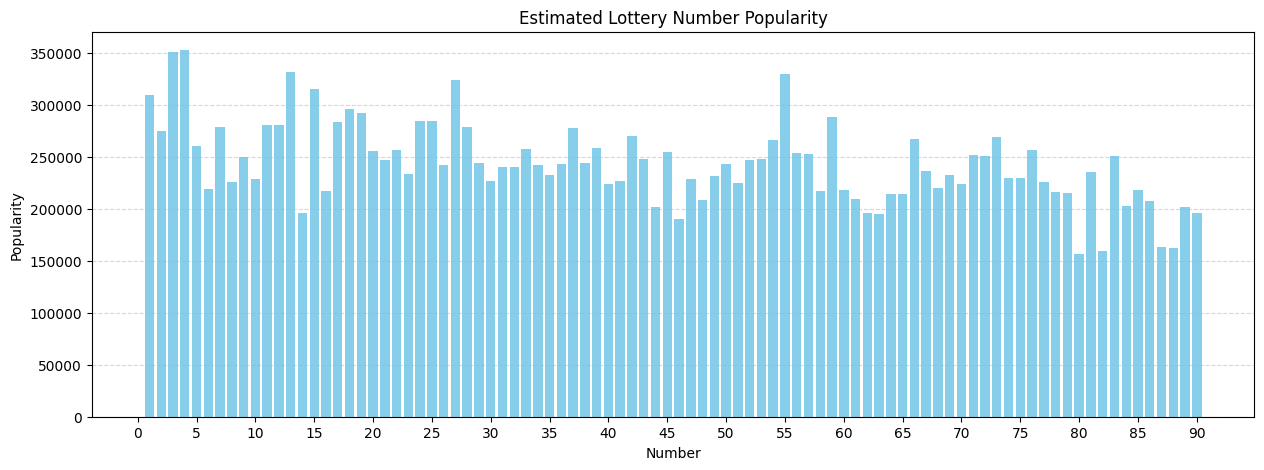

In [65]:
# Népszerű számok

import pandas as pd
from collections import defaultdict

# feltételezzük: huzasok már be van olvasva

# --- SEGÉDFÜGGVÉNY ---
def to_int_prize(x):
    """ '2 654 765 Ft' → 2654765 (opcionális) """
    if isinstance(x, str):
        return int(x.replace(" ", "").replace("Ft", ""))
    return 0

# --- NÉPSZERŰSÉG BECSLÉS (új súlyokkal) ---

# súlyok
w_twos = 1/7
w_threes = 2/7
w_fours = 4/7

popularity = defaultdict(float)

# csak a valid sorok
valid = huzasok.dropna(subset=["twos", "threes", "fours"])

for _, row in valid.iterrows():
    
    # számítsuk az egy számra jutó arányt (arányalapú becslés)
    score_twos   = (row["twos"] / 5) * w_twos
    score_threes = (row["threes"] / 5) * w_threes
    score_fours  = (row["fours"] / 5) * w_fours

    # kombinált népszerűségi érték
    draw_popularity = score_twos + score_threes + score_fours

    # minden kihúzott számhoz hozzáadjuk
    for n in [row["n1"], row["n2"], row["n3"], row["n4"], row["n5"]]:
        popularity[n] += draw_popularity

# --- EREDMÉNY: számonkénti népszerűségi táblázat ---
popularity_df = (
    pd.DataFrame({"number": range(1, 91)})
      .assign(popularity=lambda df: df["number"].map(popularity))
      .fillna(0)
      .sort_values("popularity", ascending=False)
      .reset_index(drop=True)
)

popularity_df["q"] = popularity_df["popularity"] / popularity_df["popularity"].sum()

print(popularity_df.tail(20))

import matplotlib.pyplot as plt

# Barplot
plt.figure(figsize=(15,5))
plt.bar(popularity_df["number"], popularity_df["popularity"], color="skyblue")
plt.xlabel("Number")
plt.ylabel("Popularity")
plt.title("Estimated Lottery Number Popularity")
plt.xticks(range(0, 91, 5))  # x-tengely címkék 5-ös lépésben
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()



    number  count  relative_freq
70      46     54       0.049136
71      63     54       0.049136
72      14     54       0.049136
73      48     54       0.049136
74      44     54       0.049136
75      90     53       0.048226
76      67     53       0.048226
77      58     53       0.048226
78      10     52       0.047316
79      23     52       0.047316
80      40     52       0.047316
81      60     52       0.047316
82      64     50       0.045496
83      21     49       0.044586
84       6     49       0.044586
85      87     48       0.043676
86      69     48       0.043676
87      82     45       0.040946
88      80     43       0.039126
89      88     42       0.038217


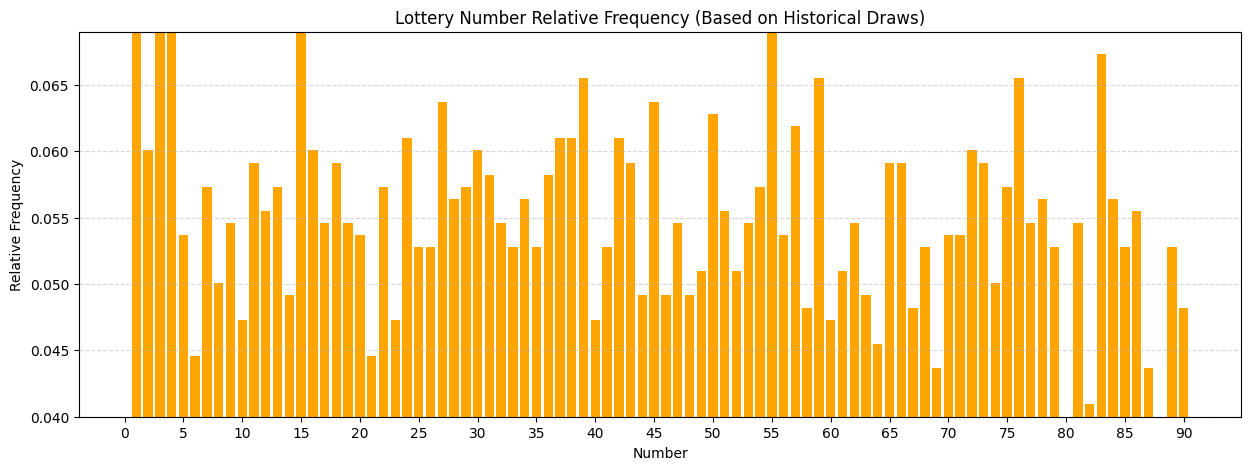

In [39]:
# Hideg/meleg számok

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# feltételezzük, hogy 'valid' már létezik a korábbi kódból
# minden húzásban az öt szám szerepel: n1-n5

# --- 1️⃣ Összesítés ---
numbers = []
for _, row in valid.iterrows():
    numbers.extend([row["n1"], row["n2"], row["n3"], row["n4"], row["n5"]])

counts = Counter(numbers)

# --- 2️⃣ Relatív gyakoriság ---
total_draws = len(valid)  # húzások száma
relative_freq = {num: counts[num]/total_draws for num in range(1,91)}

# --- 3️⃣ DataFrame készítése ---
freq_df = pd.DataFrame({
    "number": range(1,91),
    "count": [counts.get(num,0) for num in range(1,91)],
    "relative_freq": [relative_freq.get(num,0) for num in range(1,91)]
}).sort_values("count", ascending=False).reset_index(drop=True)

print(freq_df.tail(20))

# --- 4️⃣ Barplot vizualizáció ---
plt.figure(figsize=(15,5))
plt.bar(freq_df["number"], freq_df["relative_freq"], color="orange")
plt.xlabel("Number")
plt.ylabel("Relative Frequency")
plt.title("Lottery Number Relative Frequency (Based on Historical Draws)")
plt.xticks(range(0,91,5))
plt.ylim(0.04, 0.069)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


In [ ]:
for n in range(0, 15, 3):
    print(n)

1
4
7
10
13


In [88]:
# Hideg/meleg x Népszerűség

fav_df = pd.merge(freq_df[['number', 'relative_freq']],
                  popularity_df[['number', 'q']],
                  on='number')

fav_df['heat'] = fav_df['relative_freq'] * fav_df['q'] * 10_000
fav_df = fav_df.sort_values('heat', ascending=True).reset_index(drop=True)
top15 = fav_df[['number', 'heat']].head(16)

combo1 = top15.loc[[i for i in range(0, 15, 3)], 'number'] 
combo2 = top15.loc[[i for i in range(1, 15, 3)], 'number'] 
combo3 = top15.loc[[i for i in range(2, 15, 3)], 'number'] 

print(combo1.sort_values().to_list())
print(combo2.sort_values().to_list())
print(combo3.sort_values().to_list())

[6, 48, 63, 80, 87]
[14, 44, 46, 60, 88]
[58, 64, 69, 82, 90]


In [43]:
print(valid.head())

   year  week         date  fives fives_prize  fours   fours_prize  threes  \
0  2025    47  2025.11.22.      0        0 Ft     18  2 654 765 Ft    1817   
1  2025    46  2025.11.15.      0        0 Ft     48  1 023 290 Ft    2024   
2  2025    45  2025.11.08.      0        0 Ft     69    693 450 Ft    3686   
3  2025    44  2025.11.01.      0        0 Ft     21  2 135 390 Ft    2521   
4  2025    43  2025.10.25.      0        0 Ft     27  1 658 575 Ft    1762   

  threes_prize   twos twos_prize  n1  n2  n3  n4  n5  
0    27 685 Ft  53672   3 515 Ft  16  22  37  74  81  
1    25 545 Ft  51808   3 740 Ft  26  46  55  64  66  
2    13 665 Ft  75108   2 515 Ft   6  12  24  30  79  
3    18 725 Ft  67076   2 640 Ft  11  20  29  42  55  
4    26 755 Ft  52614   3 360 Ft  12  30  49  51  66  


In [ ]:
# Húzásonkénti költség/nyeremény

import pandas as pd

valid = valid[valid['date'].notna()]

# szelvényárak
szelo_arak = {
    'elotte': 130,
    '2003.04.': 150,
    '2005.03.': 175,
    '2007.11.': 200,
    '2010.02.': 225,
    '2016.11.': 250,
    '2020.01.': 300,
    '2022.10.': 350,
    '2023.09.': 400
}

# --- SEGÉDFÜGGVÉNY: dátum alapján ár kiválasztása ---
def get_ticket_price(date_str):
    date_str = date_str.rstrip('.')  # eltávolítjuk a pontot
    prev_key = 'elotte'
    for key in sorted(szelo_arak.keys()):
        if key == 'elotte':
            continue
        if date_str < key:
            return szelo_arak[prev_key]
        prev_key = key
    return szelo_arak[prev_key] if 'prev_key' in locals() else szelo_arak['elotte']

# --- Húzásonkénti összesítés --- 
summary = []

for _, row in valid.iterrows():
    price = get_ticket_price(row['date'])
    
    # kategóriák: nyertes szelvények és nyeremények
    categories = ['twos', 'threes', 'fours', 'fives']
    prize_columns = ['twos_prize', 'threes_prize', 'fours_prize', 'fives_prize']
    
    total_winners = 0
    total_prize = 0
    breakdown = {}  # bontás kategóriánként
    
    for cat, prize_col in zip(categories, prize_columns):
        winners = row[cat] if pd.notnull(row[cat]) else 0
        try:
            prize = int(str(row[prize_col]).replace(' ','').replace('Ft',''))
        except:
            prize = 0
        cat_total_prize = winners * prize
        breakdown[cat+'_prize'] = cat_total_prize
        total_winners += winners
        total_prize += cat_total_prize
    
    total_cost = total_winners * price
    relative_payout = total_prize / total_cost if total_cost > 0 else 0
    
    summary.append({
        'year': row['year'],
        'week': row['week'],
        'date': row['date'],
        'total_winners': total_winners,
        'total_prize': total_prize/1_000_000,
        'total_cost': total_cost/1_000_000,
        'relative_payout': relative_payout,
        'fives_prize': breakdown.get('fives_prize',0)/1_000_000,
        'fours_prize': breakdown.get('fours_prize',0)/1_000_000,
        'threes_prize': breakdown.get('threes_prize',0)/1_000_000,
        'twos_prize': breakdown.get('twos_prize',0)/1_000_000
    })

summary_df = pd.DataFrame(summary)

# rendezhetjük időrendbe
summary_df = summary_df.sort_values(['year','week']).reset_index(drop=True)

print(summary_df.head(20))


    year  week         date  total_winners  total_prize  total_cost  \
0   2004    45  2004.11.06.          91268   184.205358   13.690200   
1   2004    46  2004.11.13.         108962   202.655178   16.344300   
2   2004    47  2004.11.20.         123771   187.839521   18.565650   
3   2004    48  2004.11.27.          97628   192.749051   14.644200   
4   2004    49  2004.12.04.         171688   204.496768   25.753200   
5   2004    50  2004.12.11.          85917   255.972754   12.887550   
6   2004    51  2004.12.18.         147404   218.176244   22.110600   
7   2004    52  2004.12.25.         137036   218.222702   20.555400   
8   2004    53  2005.01.01.         149488   242.700166   22.423200   
9   2005     1  2005.01.08.         125806   315.879795   18.870900   
10  2005     2  2005.01.15.         149504   282.965486   22.425600   
11  2005     3  2005.01.22.         152755   289.419781   22.913250   
12  2005     4  2005.01.29.         208055  1658.735551   31.208250   
13  20

In [ ]:
ratios = pd.DataFrame({'fives/twos': summary_df['fives_prize'] / summary_df['twos_prize'],
                       'fours/twos': summary_df['fours_prize'] / summary_df['twos_prize'],
                       'threes/twos': summary_df['threes_prize'] / summary_df['twos_prize']
                       })
display(ratios.describe())
print()
display(ratios[ratios['fives/twos'] != 0].describe())

# minden esetben 4/2: 0.485 és 3/2: 0.514

,fives/twos,fours/twos,threes/twos
count,1099.000000,1099.000000,1099.000000
mean,0.785591,0.425507,0.451879
std,3.167803,0.083085,0.087075
min,0.000000,0.240515,0.252902
25%,0.000000,0.357148,0.384115
50%,0.000000,0.485044,0.513550
75%,0.000000,0.485824,0.514398
max,29.204939,0.487192,0.515866


,fives/twos,fours/twos,threes/twos
count,95.000000,95.000000,95.000000
mean,9.088047,0.435082,0.462132
std,6.400096,0.077738,0.080806
min,0.855388,0.241264,0.259607
25%,3.384319,0.361842,0.386950
50%,8.139950,0.485189,0.513797
75%,13.169428,0.485932,0.514513
max,29.204939,0.487036,0.515741


In [44]:
# EV clculation

import numpy as np
from math import comb

# hypergeom probability for YOUR ticket
def hypergeom_p(i):
    return comb(5, i) * comb(85, 5-i) / comb(90, 5)

def compute_EV_fast(your_ticket, M, popularity_df, P2, P5):
    # prize ratios
    P3 = P2 * 0.514
    P4 = P2 * 0.485

    # --- 1) Popularity → probabilities ---
    numbers = popularity_df["number"].values
    weights = popularity_df["popularity"].values
    q = weights / weights.sum()

    # indexelő tömb 1..90-ig
    prob_map = {num: q[i] for i, num in enumerate(numbers)}
    
    # --- 2) Winning ticket is symbolic: compute expected n(i) ---
    # ph = prob a random ticket hits ANY of your 5 numbers
    ph = sum(prob_map[x] for x in your_ticket)
    pm = 1 - ph

    # h[i] = prob(random player hits i numbers)
    h = {}
    for i in range(6):
        h[i] = comb(5, i) * (ph ** i) * (pm ** (5-i))

    # expected number of co-winners
    n_exp = {i: M * h[i] for i in range(6)}
    print(f"Expected co-winners n(i): {n_exp}")

    # --- 3) YOUR hypergeom hit probabilities ---
    p = {i: hypergeom_p(i) for i in range(6)}

    # --- 4) EV = sum p(i) * P(i) / n(i) ---
    P_map = {2: P2, 3: P3, 4: P4, 5: P5}

    EV = 0
    details = {}

    for i in [2,3,4,5]:
        if n_exp[i] > 0:
            term = p[i] * (P_map[i] / n_exp[i])
        else:
            term = 0
        EV += term
        details[i] = {
            "p(i)": p[i],
            "h(i)": h[i],
            "n(i)_expected": n_exp[i],
            "P(i)": P_map[i],
            "EV_contribution": term
        }

    return EV, details

# usage
your_numbers = [6, 69, 80, 82, 88]
M = 1_200_000
P2 = 90_000_000
P5 = 1_668_000_000

EV, details = compute_EV_fast(your_numbers, M, popularity_df, P2, P5)
EV, details


Expected co-winners n(i): {0: 966385.3143957863, 1: 213832.51292245387, 2: 18925.926502233597, 3: 837.5496529329135, 4: 18.532498819681454, 5: 0.16402777377976158}


(405.8933025554188,
 {2: {'p(i)': 0.02247363937893118,
   'h(i)': 0.015771605418527998,
   'n(i)_expected': 18925.926502233597,
   'P(i)': 90000000,
   'EV_contribution': 106.87072803886775},
  3: {'p(i)': 0.0008123002185155848,
   'h(i)': 0.0006979580441107613,
   'n(i)_expected': 837.5496529329135,
   'P(i)': 46260000.0,
   'EV_contribution': 44.86540944401874},
  4: {'p(i)': 9.670240696614104e-06,
   'h(i)': 1.544374901640121e-05,
   'n(i)_expected': 18.532498819681454,
   'P(i)': 43650000.0,
   'EV_contribution': 22.776529517915332},
  5: {'p(i)': 2.2753507521444952e-08,
   'h(i)': 1.3668981148313464e-07,
   'n(i)_expected': 0.16402777377976158,
   'P(i)': 1668000000,
   'EV_contribution': 231.38063555461702}})

In [ ]:
# Múlt szimuláció

import pandas as pd

valid = valid[valid['date'].notna()]

# ------------------------------------------------------------
# Szelvényárak (kulcsok lexikografikusan összehasonlítva)
# ------------------------------------------------------------
szelo_arak = {
    'elotte': 130,
    '2003.04.': 150,
    '2005.03.': 175,
    '2007.11.': 200,
    '2010.02.': 225,
    '2016.11.': 250,
    '2020.01.': 300,
    '2022.10.': 350,
    '2023.09.': 400
}

def get_ticket_price(date_str):
    date_str = date_str.rstrip('.')      # dátum: '2025.11.22'
    prev_key = 'elotte'
    for key in sorted(szelo_arak.keys()):
        if key == 'elotte':
            continue
        # szöveges összehasonlítás YYYY.MM. formában helyes
        if date_str < key:
            return szelo_arak[prev_key]
        prev_key = key
    return szelo_arak[prev_key]


# ------------------------------------------------------------
# Segédfüggvény: találatok számolása
# ------------------------------------------------------------
def count_matches(your_ticket, row):
    winning = {row["n1"], row["n2"], row["n3"], row["n4"], row["n5"]}
    return len(winning.intersection(your_ticket))


# ------------------------------------------------------------
# Nyereményszámítás 2–5 találatra
# (pool = db * prize_text)
# prize_text pl. "3 515 Ft" → számra alakítva
# ------------------------------------------------------------
def parse_prize(text):
    # pl. "2 654 765 Ft" → 2654765
    return int(text.replace(" ", "").replace("Ft", "").strip())


def compute_payout(row, matches):
    if matches == 2:
        db = row["twos"]
        prize = parse_prize(row["twos_prize"])
    elif matches == 3:
        db = row["threes"]
        prize = parse_prize(row["threes_prize"])
    elif matches == 4:
        db = row["fours"]
        prize = parse_prize(row["fours_prize"])
    elif matches == 5:
        db = row["fives"]
        prize = parse_prize(row["fives_prize"])
    else:
        return -1  # should not happen for 0/1/6 matches

    # pool / (db + 1)  → tételezzük fel, hogy TE vagy a plusz nyertes
    if prize == 0:
        return -1  # nincs kifizetés
    return (db * prize) / (db + 1)


# ------------------------------------------------------------
# Főfüggvény: teljes múltbeli szimuláció több kombinációra
# combos = lista, pl.: [(1,2,3,4,5), (4,13,55,27,15), ...]
# ------------------------------------------------------------
def simulate_history(valid_df, combos):
    result = {}

    for combo in combos:
        total_profit = 0
        weekly_results = []

        for idx, row in valid_df.iterrows():
            matches = count_matches(combo, row)
            ticket_price = get_ticket_price(row["date"])

            # 0 vagy 1 találat → veszteség: -ticket_price
            if matches < 2:
                profit = -1
            else:
                payout = compute_payout(row, matches)
                profit = payout / ticket_price

            total_profit += profit
            weekly_results.append({
                "date": row["date"],
                "matches": matches,
                "profit": profit
            })

        result[combo] = {
            "total_profit": total_profit,
            "details": weekly_results
        }

    return result


# példakombinációk
combos = [
    (4, 13, 55, 27, 15),
    (1, 2, 3, 4, 5),
    (40, 60, 80, 82, 88),
    (1, 2, 3, 4, 5),
    (16, 22, 37, 74, 81)


]

out = simulate_history(valid, combos)
for combo in combos:
    total_profit = out[combo]["total_profit"]
    print(f"\nCombo {combo}: \nTotal Profit = {total_profit:.0f}")



Combo (4, 13, 55, 27, 15): 
Total Profit = -820

Combo (1, 2, 3, 4, 5): 
Total Profit = -910

Combo (40, 60, 80, 82, 88): 
Total Profit = -871

Combo (1, 2, 3, 4, 5): 
Total Profit = -910

Combo (16, 22, 37, 74, 81): 
Total Profit = -926
